## Vision Transformer from Scratch

In [1]:
!pip install einops

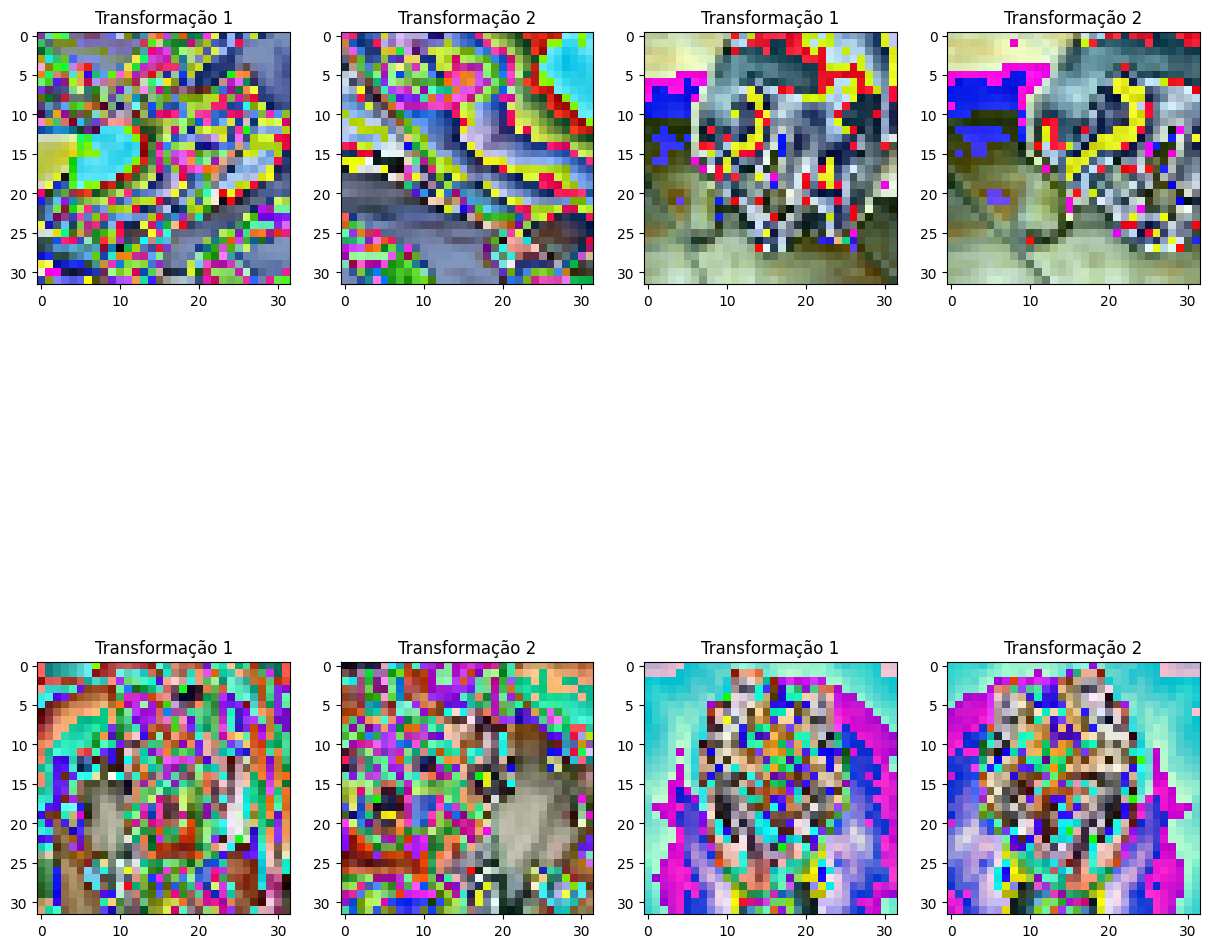

In [31]:
#Image patching

import torch
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from random import random
from torchvision.transforms import ToTensor, Resize
from torchvision.transforms.functional import to_pil_image
from torchvision import transforms, datasets

# from util import DoubleTransform

class DoubleTransform:
    def __init__(self, base_transform1, base_transform2):
        self.base_transform1 = base_transform1
        self.base_transform2 = base_transform2

    def __call__(self, x):
        return self.base_transform1(x), self.base_transform2(x)
    
normalize = transforms.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010))

train_transform = DoubleTransform(
                    transforms.Compose([
                    transforms.Resize([32, 32]),
                    transforms.ToTensor(),
                    normalize,
                    ]),
                    transforms.Compose([
                    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.)),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    normalize])
                    )
                      

# def show_images(images, num_samples=20, cols=4):
#     """Plot a set of images from the dataset.

#     Args:
#         images (_type_): _description_
#         num_samples (int, optional): _description_. Defaults to 20.
#         cols (int, optional): _description_. Defaults to 4.
#     """    

#     plt.figure(figsize=(15, 15))
#     idx=int(len(dataset)/num_samples)
#     print(images)
#     for i, img in enumerate(images):
#         if i % idx == 0:
#             plt.subplot(int(num_samples/cols) + 1, cols, int(i/idx) + 1)
#             plt.imshow(to_pil_image(img[0]))

# Função para exibir imagens

def show_images(images, num_samples=4, cols=4):
    """Exibe um conjunto de imagens."""
    plt.figure(figsize=(15, 15))
    idx = max(1, int(len(images) / num_samples))
    for i, (img_pair, _) in enumerate(images):
        if i % idx == 0 and i // idx < num_samples:
            img1, img2 = img_pair  # Obtém as duas visualizações da transformação
            
            plt.subplot(int(num_samples / cols) + 1, cols, i // idx * 2 + 1)
            plt.imshow(to_pil_image(img1))
            plt.title("Transformação 1")

            plt.subplot(int(num_samples / cols) + 1, cols, i // idx * 2 + 2)
            plt.imshow(to_pil_image(img2))
            plt.title("Transformação 2")
    plt.show()



dataset = OxfordIIITPet(root=".", transform=train_transform, download=True)

show_images(dataset)

## Patch Images

In [32]:
from torch import nn
from einops.layers.torch import Rearrange
from torch import Tensor


class PatchEmbedding(nn.Module):
    def __init__(self, in_channels = 3, patch_size = 8, emb_size = 128):
        self.patch_size = patch_size
        super().__init__()
        self.projection = nn.Sequential(
            # break-down the image in s1 x s2 patches and flat them
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size),
            nn.Linear(patch_size * patch_size * in_channels, emb_size)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.projection(x)
        return x

In [4]:
# # Run a quick test
# sample_datapoint = torch.unsqueeze(dataset[0], 0)
# print("Initial shape: ", sample_datapoint.shape)
# embedding = PatchEmbedding()(sample_datapoint)
# print("Patches shape: ", embedding.shape)

## Model

CLS Token:
- No contexto do Vision Transformer, o CLS token é aplicado de forma semelhante. No ViT, uma imagem é dividida em patches (fragmentos) que são então linearizados e embutidos. Junto com esses embutidos de patches, é adicionado um token especial, o CLS token, no início da sequência de patches. O ViT então processa essa sequência de tokens, incluindo o CLS token, através de camadas de transformadores.

- Após o processamento, o vetor de saída correspondente ao CLS token é usado como uma representação agregada da imagem inteira e é passado para a camada de classificação final para realizar a tarefa específica (por exemplo, classificação de imagens).

- Em resumo, o CLS token no Vision Transformer serve como um ponto de agregação que resume a informação da imagem inteira para facilitar tarefas de classificação.


Positional Embedding:
- É um mecanismo utilizado para incorporar informações sobre a posição dos patches de imagem na sequência de entrada para o modelo transformer.

In [33]:
from einops import rearrange

class Attention(nn.Module):
    def __init__(self, dim, n_heads, dropout):
        super().__init__()
        self.n_heads = n_heads
        self.attention = nn.MultiheadAttention(embed_dim=dim,
                                               num_heads=n_heads,
                                               dropout=dropout)
        self.q = torch.nn.Linear(dim, dim)
        self.k = torch.nn.Linear(dim, dim)
        self.v = torch.nn.Linear(dim, dim)
    
    def forward(self, x):
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        attention_output, attention_output_weights = self.attention(q, k, v)
        return attention_output

In [34]:
Attention(dim=128, n_heads=4, dropout=0.)(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [35]:
class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)

In [36]:
norm = PreNorm(128, Attention(dim=128, n_heads=4, dropout=0.))
norm(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [37]:
class FeedForward(nn.Sequential):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

In [38]:
ff = FeedForward(dim=128, hidden_dim=256)
ff(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

In [39]:
class ResidualAdd(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        res = x
        x = self.fn(x, **kwargs)
        x += res
        return x 

In [40]:
residual_attention = ResidualAdd(Attention(dim=128, n_heads=4, dropout=0.))
residual_attention(torch.ones((1, 5, 128))).shape

torch.Size([1, 5, 128])

- Not all parameters are like in the original implementation
- Some dropouts and norms are missing
- ToDo: Checar a implementação do google research no github

In [41]:
from einops import repeat

class ViT(nn.Module):
    def __init__(self, 
                 channels: int = 3,
                 image_size: int = 144,
                 patch_size: int = 8,
                 emb_size: int = 32,
                 n_layers: int = 4,
                 out_dim: int = 37,
                 dropout: float = 0.1,
                 n_heads: int = 2):
        super(ViT, self).__init__()

        #Atributos
        self.channels = channels
        self.height = image_size
        self.widht = image_size
        self.patch_size = patch_size
        self.n_layers = n_layers

        #Patching
        self.patch_embedding = PatchEmbedding(in_channels=channels, 
                                              patch_size=patch_size, 
                                              emb_size=emb_size)
            
        #Learnable params
        num_patches = (image_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, emb_size))
        self.cls_token = nn.Parameter(torch.rand(1, 1, emb_size))

        #Encoder
        self.layers = nn.ModuleList([])
        for _ in range(n_layers):
            transformer_block = nn.Sequential(
                ResidualAdd(PreNorm(emb_size, Attention(dim=emb_size, n_heads=n_heads, dropout=dropout))),
                ResidualAdd(PreNorm(emb_size, FeedForward(dim=emb_size, hidden_dim=emb_size, dropout=dropout)))
            )
            self.layers.append(transformer_block)
        
        #Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, out_dim)
        )


    def forward(self, image):

        #Get patch embedding vectos
        x = self.patch_embedding(image)
        b, n, _ = x.shape

        #Add class (cls) token and position embedding
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        
        #Transformer layers / pass through the layers
        for i in range(self.n_layers):
            x = self.layers[i](x)
        
        #Ouput based on the classification token
        return self.head(x[:, 0, :])

In [42]:
model = ViT()
print(model)
model(torch.ones((1, 3, 144, 144)))

ViT(
  (patch_embedding): PatchEmbedding(
    (projection): Sequential(
      (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=8, p2=8)
      (1): Linear(in_features=192, out_features=32, bias=True)
    )
  )
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): ResidualAdd(
        (fn): PreNorm(
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (fn): Attention(
            (attention): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
            )
            (q): Linear(in_features=32, out_features=32, bias=True)
            (k): Linear(in_features=32, out_features=32, bias=True)
            (v): Linear(in_features=32, out_features=32, bias=True)
          )
        )
      )
      (1): ResidualAdd(
        (fn): PreNorm(
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
          (fn): FeedForward(
            (net): Sequential(
           

tensor([[-0.5069,  0.0654, -0.1658, -0.4100, -0.0554, -0.5426,  0.6378,  0.7976,
          0.6331,  1.4992, -0.1949, -0.1524,  0.0763,  0.2318, -0.8215, -0.1646,
         -0.6524,  0.0178, -0.3811, -1.3519, -0.1380,  0.8777, -0.1413, -0.1838,
         -0.5399, -0.0695,  0.5190, -0.5556, -0.0022,  0.0620, -0.2965, -0.9898,
         -0.3224,  0.0604, -1.2636,  1.0507,  0.7746]],
       grad_fn=<AddmmBackward0>)

## Training

In [43]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

train_split = int(0.8 * len(dataset))
train, test = random_split(dataset, [train_split, len(dataset) - train_split])

In [44]:
train_dataloader = DataLoader(train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test, batch_size=32, shuffle=True)

<h1> SupCon loss ok <h1>

In [21]:
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT().to(device)
#optimizer = optim.AdamW(model.parameters(), lr=0.001)
#criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

from losses import SupConLoss
criterion = SupConLoss(temperature=0.07)


for epoch in range(100):
    epoch_losses = []
    model.train()
        
    for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
        images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
        images, labels = images.to(device), labels.to(device)

        bsz = labels.shape[0]
        # print(images.shape)
        with torch.set_grad_enabled(True):
            flat_embeds = model(images)
        # reshape from (2B, D) to (B, 2, D)
        embeds = torch.cat([aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

        # print(embeds.shape)

        # outputs = model(images)
        loss = criterion(embeds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f">>> Epoch {epoch} train loss: ", np.mean(epoch_losses))
        epoch_losses = []
        # Something was strange when using this?
        # model.eval()
        for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
            images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
            images, labels = images.to(device), labels.to(device)
            # outputs = model(images)
            bsz = labels.shape[0]


            # forward
            with torch.no_grad():
                flat_embeds = model(images)
            # reshape from (2B, D) to (B, 2, D)
            embeds = torch.cat(
                [aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

            loss = criterion(embeds, labels)
            epoch_losses.append(loss.item())

       
        print(f">>> Epoch {epoch} test loss: ", np.mean(epoch_losses))

>>> Epoch 0 train loss:  4.347386090651803
>>> Epoch 0 test loss:  4.147310060003529
>>> Epoch 5 train loss:  4.14604029448136
>>> Epoch 5 test loss:  4.146381523298181
>>> Epoch 10 train loss:  4.145478813544564
>>> Epoch 10 test loss:  4.144502012625985
>>> Epoch 15 train loss:  4.143822633701822
>>> Epoch 15 test loss:  4.1442906597386235
>>> Epoch 20 train loss:  4.144179059111553
>>> Epoch 20 test loss:  4.143609850302987
>>> Epoch 25 train loss:  4.143514747204988
>>> Epoch 25 test loss:  4.144213925237241
>>> Epoch 30 train loss:  4.144117443457894
>>> Epoch 30 test loss:  4.143834995186848
>>> Epoch 35 train loss:  4.144091989683068
>>> Epoch 35 test loss:  4.143550437429677
>>> Epoch 40 train loss:  4.1439375721889995
>>> Epoch 40 test loss:  4.143451996471571
>>> Epoch 45 train loss:  4.144744510235994
>>> Epoch 45 test loss:  4.144541185835133
>>> Epoch 50 train loss:  4.144187191258306
>>> Epoch 50 test loss:  4.142818528672923
>>> Epoch 55 train loss:  4.143362299255703
>>

In [ ]:
# embeds, labels = next(iter(test_dataloader))
# embeds, labels = embeds.to(device), labels.to(device)
# outputs = model(embeds)

# print("Predicted classes", outputs.argmax(-1))
# print("Actual classes", labels)

AttributeError: 'list' object has no attribute 'to'

<h1> Testando SimCLR <h1>

In [25]:
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT().to(device)
#optimizer = optim.AdamW(model.parameters(), lr=0.001)
#criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

from losses import SupConLoss
criterion = SupConLoss(temperature=0.07)


for epoch in range(20):
    epoch_losses = []
    model.train()
        
    for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
        images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
        images, labels = images.to(device), labels.to(device)

        bsz = labels.shape[0]
        # print(images.shape)
        with torch.set_grad_enabled(True):
            flat_embeds = model(images)
        # reshape from (2B, D) to (B, 2, D)
        embeds = torch.cat([aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

        # print(embeds.shape)

        # outputs = model(images)
        # loss = criterion(embeds, labels)
        loss = criterion(embeds)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f">>> Epoch {epoch} train loss: ", np.mean(epoch_losses))
        epoch_losses = []
        # Something was strange when using this?
        # model.eval()
        for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
            images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
            images, labels = images.to(device), labels.to(device)
            # outputs = model(images)
            bsz = labels.shape[0]


            # forward
            with torch.no_grad():
                flat_embeds = model(images)
            # reshape from (2B, D) to (B, 2, D)
            embeds = torch.cat(
                [aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

            loss = criterion(embeds, labels)
            epoch_losses.append(loss.item())

       
        print(f">>> Epoch {epoch} test loss: ", np.mean(epoch_losses))

>>> Epoch 0 train loss:  4.523763112399889
>>> Epoch 0 test loss:  4.15225827175638
>>> Epoch 5 train loss:  4.145499789196512
>>> Epoch 5 test loss:  4.145238166270048
>>> Epoch 10 train loss:  4.144453727680704
>>> Epoch 10 test loss:  4.144667402557705
>>> Epoch 15 train loss:  4.144812661668529
>>> Epoch 15 test loss:  4.1438203998233964


In [47]:
import torch.optim as optim
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT().to(device)
#optimizer = optim.AdamW(model.parameters(), lr=0.001)
#criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

from losses import MultiviewEpsSupInfoNCELoss
criterion = MultiviewEpsSupInfoNCELoss(temperature=0.07, epsilon=0.25)


for epoch in range(20):
    epoch_losses = []
    model.train()
        
    for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
        images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
        images, labels = images.to(device), labels.to(device)

        bsz = labels.shape[0]
        # print(images.shape)
        with torch.set_grad_enabled(True):
            flat_embeds = model(images)
        # reshape from (2B, D) to (B, 2, D)
        embeds = torch.cat([aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

        # print(embeds.shape)

        # outputs = model(images)
        # loss = criterion(embeds, labels)
        loss = criterion(embeds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f">>> Epoch {epoch} train loss: ", np.mean(epoch_losses))
        epoch_losses = []
        # Something was strange when using this?
        # model.eval()
        for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
            images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
            images, labels = images.to(device), labels.to(device)
            # outputs = model(images)
            bsz = labels.shape[0]


            # forward
            with torch.no_grad():
                flat_embeds = model(images)
            # reshape from (2B, D) to (B, 2, D)
            embeds = torch.cat(
                [aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

            loss = criterion(embeds, labels)
            epoch_losses.append(loss.item())

       
        print(f">>> Epoch {epoch} test loss: ", np.mean(epoch_losses))

>>> Epoch 0 train loss:  4.321650613909182
>>> Epoch 0 test loss:  4.1199345640514204
>>> Epoch 5 train loss:  4.116508789684461
>>> Epoch 5 test loss:  4.113694973613905
>>> Epoch 10 train loss:  4.114948143129763
>>> Epoch 10 test loss:  4.115034067112466
>>> Epoch 15 train loss:  4.113653820493947
>>> Epoch 15 test loss:  4.112261735874673


In [ ]:
import torch.optim as optim
import numpy as np

device = torch.device("cuda")
model = ViT().to(device)
#optimizer = optim.AdamW(model.parameters(), lr=0.001)
#criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

from losses import InfoNCELoss
criterion = InfoNCELoss(temperature=0.07)

for epoch in range(20):
    epoch_losses = []
    model.train()
        
    for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
        images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
        images, labels = images.to(device), labels.to(device)

        bsz = labels.shape[0]
        # print(images.shape)
        with torch.set_grad_enabled(True):
            flat_embeds = model(images)
        # reshape from (2B, D) to (B, 2, D)
        embeds = torch.cat([aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

        # print(embeds.shape)

        # outputs = model(images)
        # loss = criterion(embeds, labels)
        loss = criterion(embeds)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    if epoch % 5 == 0:
        print(f">>> Epoch {epoch} train loss: ", np.mean(epoch_losses))
        epoch_losses = []
        # Something was strange when using this?
        # model.eval()
        for step, (images_aug_tuple, labels) in enumerate(train_dataloader): #images_aug_tuple: (B, 2, C, H, W) -> is a list 
            images = torch.cat([images_aug_tuple[0], images_aug_tuple[1]], dim=0) # (2B, C, H, W) -> (B, 2, C, H, W)
            images, labels = images.to(device), labels.to(device)
            # outputs = model(images)
            bsz = labels.shape[0]


            # forward
            with torch.no_grad():
                flat_embeds = model(images)
            # reshape from (2B, D) to (B, 2, D)
            embeds = torch.cat(
                [aug.unsqueeze(1) for aug in torch.split(flat_embeds, [bsz, bsz], dim=0)], dim=1)

            loss = criterion(embeds, labels)
            epoch_losses.append(loss.item())

       
        print(f">>> Epoch {epoch} test loss: ", np.mean(epoch_losses))

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [6]:
import timm

timm.list_models("vit*")

['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384',
 'vit_base_patch32_clip_224',
 'vit_base_patch32_clip_256',
 'vit_base_patch32_clip_384',
 'vit_base_patch32_clip_448',
 'vit_base_patch32_clip_quickgelu_224',
 'vit_base_pa